In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Dataset Features (X) shape:", X.shape)
print("Dataset Labels (y) shape:", y.shape)
print("Feature Names:", feature_names)
print("Target Names:", target_names)

Dataset Features (X) shape: (150, 4)
Dataset Labels (y) shape: (150,)
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: ['setosa' 'versicolor' 'virginica']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 105
Test set size: 45


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized.")

Features standardized.


In [5]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

print("Hyperparameter grid defined:")

for param, values in param_grid.items():
    print(param, ":", values)

Hyperparameter grid defined:
C : [0.1, 1, 10, 100]
gamma : [1, 0.1, 0.01, 0.001]
kernel : ['rbf', 'linear']


In [6]:
grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

print("Starting Grid Search with 5-fold Cross-Validation...")

Starting Grid Search with 5-fold Cross-Validation...


In [7]:
grid_search.fit(X_train_scaled, y_train)

print("Grid Search completed.")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Grid Search completed.


In [8]:
print("Best hyperparameters found:")
print(grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(grid_search.best_score_)

Best hyperparameters found:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

Best cross-validation accuracy:
0.980952380952381


In [9]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_scaled)

test_accuracy_tuned = accuracy_score(
    y_test,
    y_pred_tuned
)

print("Test set accuracy with tuned model:")
print(test_accuracy_tuned)

Test set accuracy with tuned model:
0.9111111111111111


In [10]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



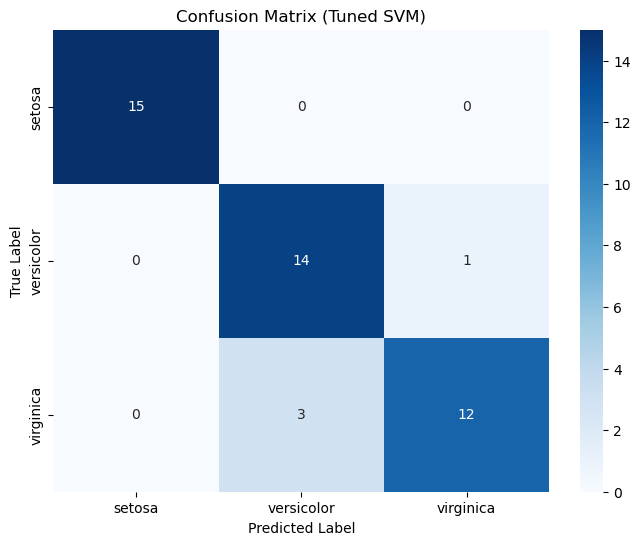

In [11]:
cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title('Confusion Matrix (Tuned SVM)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [12]:
results_df = pd.DataFrame(
    grid_search.cv_results_
)

top5 = results_df[
    [
        'param_C',
        'param_gamma',
        'param_kernel',
        'mean_test_score',
        'rank_test_score'
    ]
].sort_values(
    by='rank_test_score'
).head(5)

print("Top 5 Grid Search Results:")

display(top5)

Top 5 Grid Search Results:


,param_C,param_gamma,param_kernel,mean_test_score,rank_test_score
10,1.0,0.100,rbf,0.980952,1
27,100.0,0.100,linear,0.980952,1
31,100.0,0.001,linear,0.980952,1
29,100.0,0.010,linear,0.980952,1
25,100.0,1.000,linear,0.980952,1


In [13]:
model_cv = SVC(random_state=42)

print("SVM model created.")

SVM model created.


In [14]:
k_folds = 5

kf = KFold(
    n_splits=k_folds,
    shuffle=True,
    random_state=42
)

print("Number of folds:", k_folds)

Number of folds: 5


In [15]:
cv_scores = cross_val_score(
    model_cv,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring='accuracy'
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean cross-validation accuracy:")
print(np.mean(cv_scores))

print("\nStandard deviation:")
print(np.std(cv_scores))

Cross-validation scores:
[1.         0.95238095 0.95238095 0.95238095 1.        ]

Mean cross-validation accuracy:
0.9714285714285713

Standard deviation:
0.023328473740792197


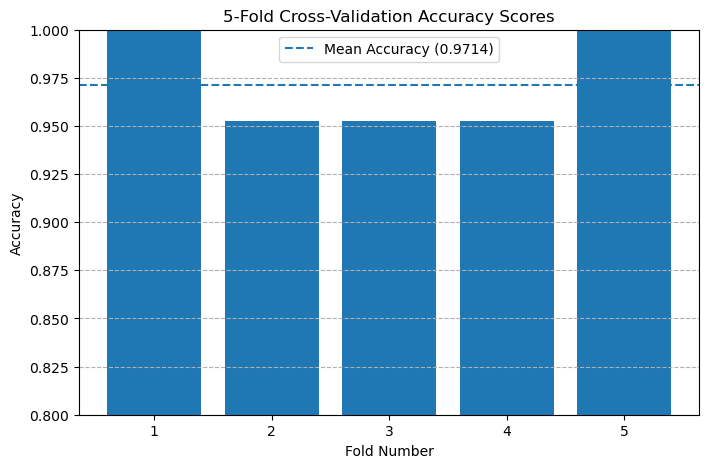

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, k_folds + 1),
    cv_scores
)

plt.axhline(
    y=np.mean(cv_scores),
    linestyle='--',
    label=f'Mean Accuracy ({np.mean(cv_scores):.4f})'
)

plt.title('5-Fold Cross-Validation Accuracy Scores')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')

plt.ylim(0.8, 1.0)

plt.legend()
plt.grid(axis='y', linestyle='--')

plt.show()

In [17]:
print("--- Why is Cross-Validation Important? ---")

print("1. More Reliable Performance Estimate")
print("   Reduces bias from a single train-test split.")

print("\n2. Better Generalization")
print("   Helps ensure the model performs well on unseen data.")

print("\n3. Efficient Data Usage")
print("   All data points are used for training and validation.")

print("\n4. Detects Overfitting/Underfitting")
print("   Variation in scores can indicate model instability.")

--- Why is Cross-Validation Important? ---
1. More Reliable Performance Estimate
   Reduces bias from a single train-test split.

2. Better Generalization
   Helps ensure the model performs well on unseen data.

3. Efficient Data Usage
   All data points are used for training and validation.

4. Detects Overfitting/Underfitting
   Variation in scores can indicate model instability.
